# 3. EDA General

### Barras de SEX, EDUCATION y MARRIAGE

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

df = pd.read_csv(r"C:\Users\Emiliano\Desktop\BLUEPRUEBA\default_limpio.csv")
print("Shape:", df.shape)
df.head()

Shape: (30000, 24)


,LIMIT_BAL,SEX,EDUCATION,MARRIAGE,AGE,PAY_0,PAY_2,PAY_3,PAY_4,PAY_5,...,BILL_AMT4,BILL_AMT5,BILL_AMT6,PAY_AMT1,PAY_AMT2,PAY_AMT3,PAY_AMT4,PAY_AMT5,PAY_AMT6,default payment next month
0,20000,2.0,2.0,1.0,24.0,2,2,-1,-1,-2,...,0,0,0,0,689,0,0,0,0,1
1,120000,2.0,2.0,2.0,26.0,-1,2,0,0,0,...,3272,3455,3261,0,1000,1000,1000,0,2000,1
2,90000,2.0,2.0,2.0,34.0,0,0,0,0,0,...,14331,14948,15549,1518,1500,1000,1000,1000,5000,0
3,50000,2.0,2.0,1.0,37.0,0,0,0,0,0,...,28314,28959,29547,2000,2019,1200,1100,1069,1000,0
4,50000,1.0,2.0,1.0,57.0,-1,0,-1,0,0,...,20940,19146,19131,2000,36681,10000,9000,689,679,0


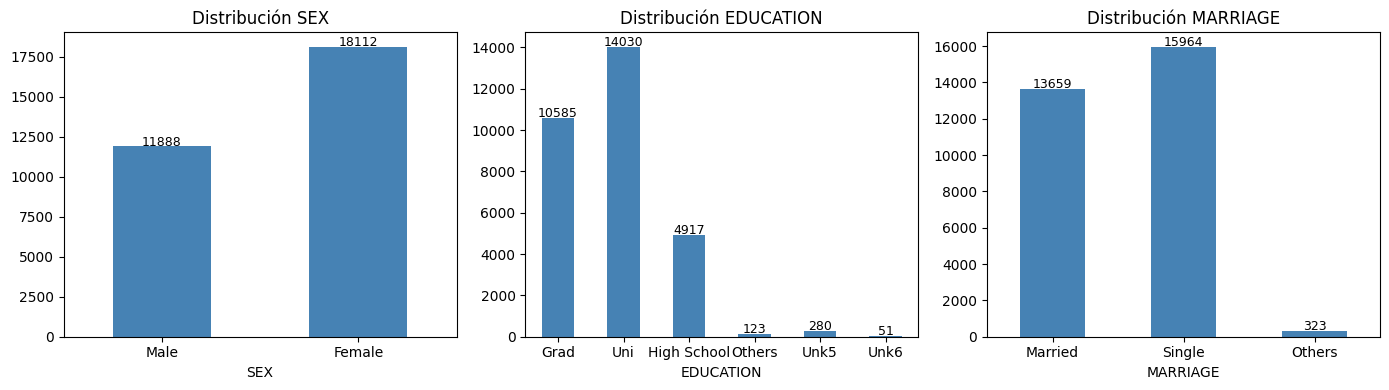

In [4]:
fig, axes = plt.subplots(1, 3, figsize=(14, 4))

def bar_con_valores(ax, columna, etiquetas, titulo):
    counts = df[columna].value_counts().sort_index()
    counts.plot(kind="bar", ax=ax, color="steelblue")
    ax.set_title(titulo)
    ax.set_xticklabels(etiquetas, rotation=0)
    for i, v in enumerate(counts):
        ax.text(i, v + 50, str(v), ha="center", fontsize=9)

bar_con_valores(axes[0], "SEX",      ["Male", "Female"],                    "Distribución SEX")
bar_con_valores(axes[1], "EDUCATION", ["Grad", "Uni", "High School", "Others", "Unk5", "Unk6"], "Distribución EDUCATION")
bar_con_valores(axes[2], "MARRIAGE",  ["Married", "Single", "Others"],       "Distribución MARRIAGE")

plt.tight_layout()
plt.show()

### Histograma AGE

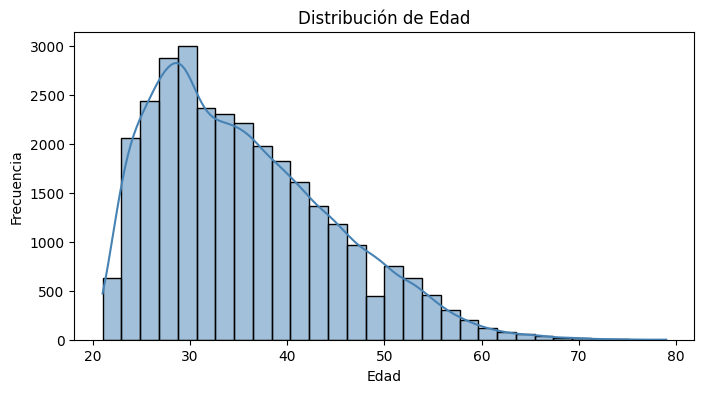

In [5]:
plt.figure(figsize=(8, 4))
sns.histplot(df["AGE"], bins=30, kde=True, color="steelblue")
plt.title("Distribución de Edad")
plt.xlabel("Edad")
plt.ylabel("Frecuencia")
plt.show()

### Histograma LIMIT_BAL:

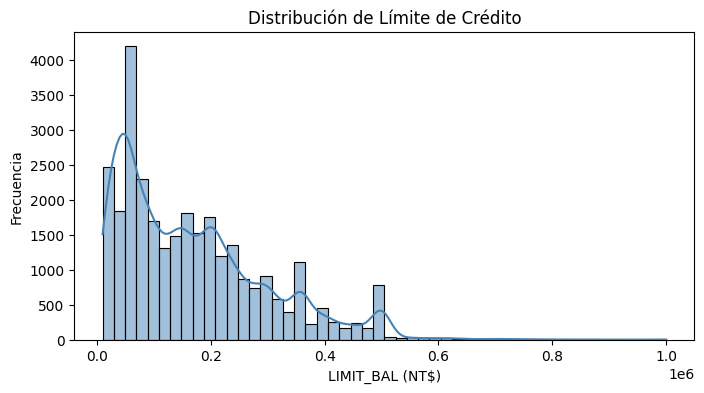

In [6]:
plt.figure(figsize=(8, 4))
sns.histplot(df["LIMIT_BAL"], bins=50, kde=True, color="steelblue")
plt.title("Distribución de Límite de Crédito")
plt.xlabel("LIMIT_BAL (NT$)")
plt.ylabel("Frecuencia")
plt.show()

### Heatmap de correlación:

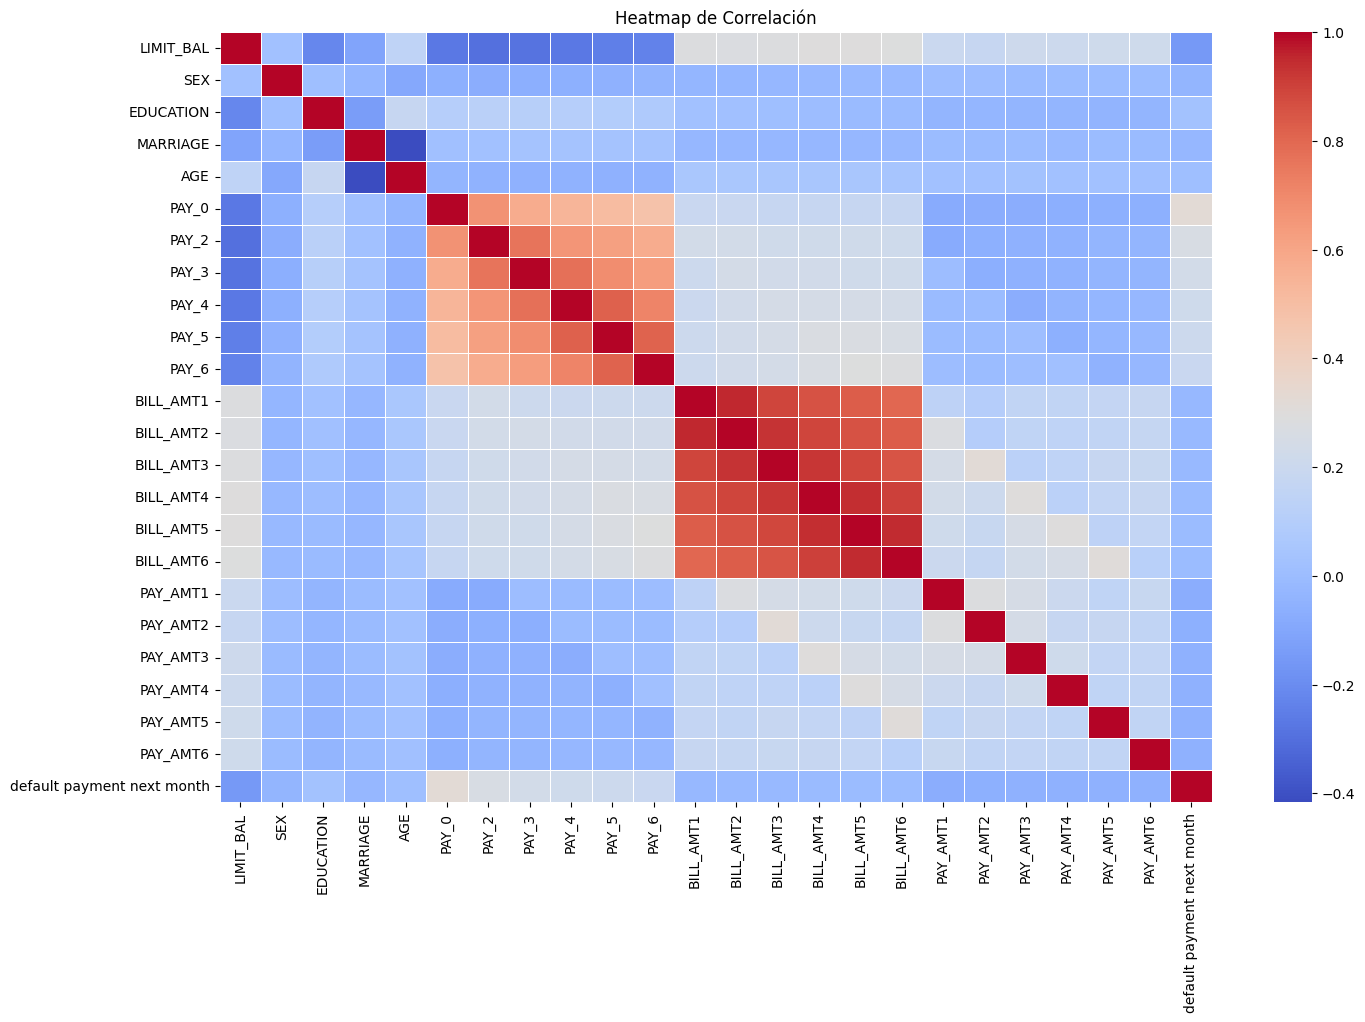

In [7]:
plt.figure(figsize=(16, 10))
sns.heatmap(df.corr(), annot=False, cmap="coolwarm", linewidths=0.5)
plt.title("Heatmap de Correlación")
plt.show()

### Boxplots BILL_AMT y PAY_AMT:

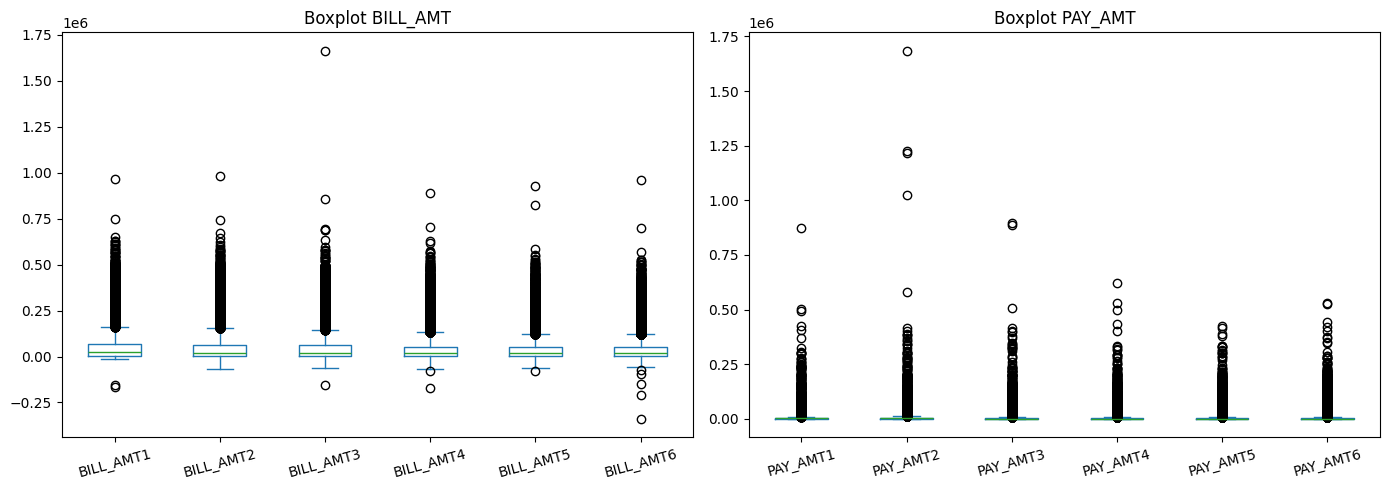

In [8]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

cols_bill = ["BILL_AMT1","BILL_AMT2","BILL_AMT3","BILL_AMT4","BILL_AMT5","BILL_AMT6"]
cols_pay  = ["PAY_AMT1","PAY_AMT2","PAY_AMT3","PAY_AMT4","PAY_AMT5","PAY_AMT6"]

df[cols_bill].plot(kind="box", ax=axes[0], vert=True)
axes[0].set_title("Boxplot BILL_AMT")
axes[0].tick_params(axis='x', rotation=15)

df[cols_pay].plot(kind="box", ax=axes[1], vert=True)
axes[1].set_title("Boxplot PAY_AMT")
axes[1].tick_params(axis='x', rotation=15)

plt.tight_layout()
plt.show()